# Radar vegetation phenology using Sentinel-1 <img align="right" src="../Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Products used:** 
[ga_s1_rtc_backscatter_experimental](https://explorer.dev.dea.ga.gov.au/products/ga_s1_rtc_backscatter_experimental)

## Background
Phenology is the study of plant and animal life cycles in the context of the seasons.  It can be useful in understanding the life cycle trends of crops and how the growing seasons are affected by changes in climate. However, in cloudy regions optical satellites may not view the vegetation cycle during key moments of growth (e.g. during the peak of the growing sesaon) leading to inaccurate estimates of vegetation phenology variables.  The Sentinel-1 radar satellite 'sees' through clouds and can, in theory, view the entire life cycle of plants. This notebook will use Sentinel-1 to derive key phenology statistics.  You can compare these results with the results from the [Sentinel-2 vegetation phenology notebook](Phenology_optical.ipynb) which relies on optical data to calculate phenology over the same region as this notebook

## Description

This notebook demonstrates how to calculate vegetation phenology statistics over cropping regions using the DE Africa function `xr_phenology`  To detect changes in plant life for Sentinel-1, the script uses the **Radar Vegetation Index**

The outputs of this notebook can be used to assess spatio-temporal differences in the growing seasons of agriculture fields or native vegetation.

This notebook demonstrates the following steps:

1. Load Sentinel 1 data for an area of interest.
2. pre-process S1 data
3. Calculate the radar vegetation index.
4. Plot false colour images of the region.
5. Compute the radar vegetation index
6. Smooth the vegetation timeseries to minimize noise.
7. Calculate per-pixel phenology statistics

***

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages
Load key Python packages and supporting functions for the analysis.

In [1]:
# !pip uninstall dea-tools -y

In [2]:
%matplotlib inline

# import datetime as dt
# from datetime import datetime
# import os

import numpy as np
import pandas as pd
import xarray as xr
# import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.ndimage import uniform_filter

from pystac_client import Client
from odc.stac import load, configure_s3_access
from odc.geo import BoundingBox

import sys
sys.path.insert(1, '../Tools/')
from dea_tools.bandindices import dualpol_indices
from dea_tools.plotting import display_map, rgb
from dea_tools.temporal import xr_phenology


### Connect to the datacube

In [3]:
catalog = "https://explorer.dev.dea.ga.gov.au/stac"

stac_client = Client.open(catalog)

configure_s3_access(
    cloud_defaults=True,
    aws_unsigned=True,
)

### Analysis parameters


In [4]:
# Set the central latitude and longitude
central_lat = -35.0870
central_lon = 147.2522

# Set the buffer to load around the central coordinates. 
buffer = 0.025

# Compute the bounding box for the study area
latitude = (central_lat - buffer, central_lat + buffer)
longitude = (central_lon - buffer, central_lon + buffer)

bbox = BoundingBox(
    left=central_lon - buffer,
    bottom=central_lat - buffer,
    right=central_lon + buffer,
    top=central_lat + buffer,
    crs="EPSG:4326"
)

start_date = "2024-01-01"
end_date = "2024-12-31"

## View the selected location
The next cell will display the selected area on an interactive map.
Feel free to zoom in and out to get a better understanding of the area you'll be analysing.
Clicking on any point of the map will reveal the latitude and longitude coordinates of that point.

In [5]:
display_map(x=longitude, y=latitude)

## Load Sentinel-1 data

The first step is to load Sentinel-1 data for the specified area of interest and time range. The `load_ard` function is used here to load data that has been masked using quality filters, making it ready for analysis.

In [6]:
collections_query = ["ga_s1_rtc_backscatter_experimental"]
date_query = f"{start_date}/{end_date}"
bbox_query = bbox.bbox

items = stac_client.search(
    collections=collections_query,
    datetime=date_query,
    bbox=bbox_query
).item_collection()

print(f"Found {len(items)} items")

Found 222 items


In [7]:
# Load our filtered data
ds_s1 = load(
    items,
    crs="EPSG:3577",
    chunks={},
    resolution=20,
    groupby="solar_day",
    bbox=bbox,
).compute()

ds_s1

/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


<xarray.Dataset> Size: 49MB
Dimensions:      (y: 305, x: 260, time: 51)
Coordinates:
  * y            (y) float64 2kB -3.911e+06 -3.911e+06 ... -3.918e+06 -3.918e+06
  * x            (x) float64 2kB 1.381e+06 1.381e+06 ... 1.387e+06 1.387e+06
    spatial_ref  int32 4B 3577
  * time         (time) datetime64[ns] 408B 2024-02-06T19:24:50.417537 ... 20...
Data variables:
    VH           (time, y, x) float32 16MB 0.02594 0.03286 0.02609 ... nan nan
    VV           (time, y, x) float32 16MB 0.1795 0.05979 0.05304 ... nan nan
    mask         (time, y, x) float32 16MB 0.0 0.0 0.0 0.0 ... nan nan nan nan

### Visualise loaded data

Sentinel-1 backscatter data has two measurements, *VV* and *VH*, which correspond to the polarisation of the light sent and received by the satellite.
*VV* refers to the satellite sending out vertically-polarised light and receiving vertically-polarised light back, whereas *VH* refers to the satellite sending out vertically-polarised light and receiving horizontally-polarised light back.
These two measurement bands can tell us different information about the area we're studying. 

When working with radar backscatter, it is common to work with the data in units of decibels (dB), rather than digital number (DN) as measured by the satellite.
To convert from DN to dB, we use the following formula:

$$
\begin{aligned}
\text{dB} = 10 \times \log_{10}(\text{DN}).
\end{aligned}
$$


In [8]:
def dB_scale(data): 
    '''Scales a xarray.DataArray with linear DN to a dB scale.'''
    # Explicitly set negative data to nan to avoid log of negative number
    negative_free_data = data.where(data >= 0, np.nan)
    return 10 * np.log10(negative_free_data)

# Scale to plot data in decibels
ds_s1["vh_dB"] = dB_scale(ds_s1.VH)
# Scale to plot data in decibels
ds_s1["vv_dB"] = dB_scale(ds_s1.VV)


## Preprocessing the data through filtering

### Speckle Filtering using Lee Filter


In [9]:
# Adapted from https://stackoverflow.com/questions/39785970/speckle-lee-filter-in-python

def lee_filter(img, size):
    """
    Applies the Lee filter to reduce speckle noise in an image.

    Parameters:
    img (ndarray): Input image to be filtered.
    size (int): Size of the uniform filter window.

    Returns:
    ndarray: The filtered image.
    """
    img_mean = uniform_filter(img, size)
    img_sqr_mean = uniform_filter(img**2, size)
    img_variance = img_sqr_mean - img_mean**2

    overall_variance = np.var(img)

    img_weights = img_variance / (img_variance + overall_variance)
    img_output = img_mean + img_weights * (img - img_mean)
    return img_output

# Define a function to apply the Lee filter to a DataArray
def apply_lee_filter(data_array, size=7):
    """
    Applies the Lee filter to the provided DataArray.

    Parameters:
    data_array (xarray.DataArray): The data array to be filtered.
    size (int): Size of the uniform filter window. Default is 7.

    Returns:
    xarray.DataArray: The filtered data array.
    """
    data_array_filled = data_array.fillna(0)
    filtered_data = xr.apply_ufunc(
        lee_filter, data_array_filled,
        kwargs={"size": size},
        input_core_dims=[["y", "x"]],
        output_core_dims=[["y", "x"]],
        dask_gufunc_kwargs={"allow_rechunk": True},
        vectorize=True,
        dask="parallelized",
        output_dtypes=[data_array.dtype]
    )
    return filtered_data

In [10]:
# The lee filter above doesn't handle null values
# We therefore set null values to 0 before applying the filter
valid = np.isfinite(ds_s1)
ds_s1 = ds_s1.where(valid, 0)

ds_s1["vh_dB_filtered"] = apply_lee_filter(ds_s1.vh_dB, size = 7)
ds_s1["vv_dB_filtered"] = apply_lee_filter(ds_s1.vv_dB, size = 7)

# ds_s1["vh_dB_filtered"] = ds_s1["vh_dB_filtered"].where(~np.isnan(mean_vv_dB))
# ds_s1["vv_dB_filtered"] = ds_s1["vv_dB_filtered"].where(~np.isnan(mean_vv_dB))


### False colour RGB plots
Now can plot some of the Sentinel-1 images as false colour images using the `rgb` function. Notice that the backscatter intensity of the cropping regions is changing throughout the year as the plants in the fields go through their growth and senescence cycle.

In [11]:
# VH/VV will help create an RGB image
ds_s1["vh/vv"] = ds_s1.VH / ds_s1.VV

# median values are used to scale the measurements so they have a similar range for visualization
med_s1 = ds_s1[["VV", "VH", "vh/vv"]].median()

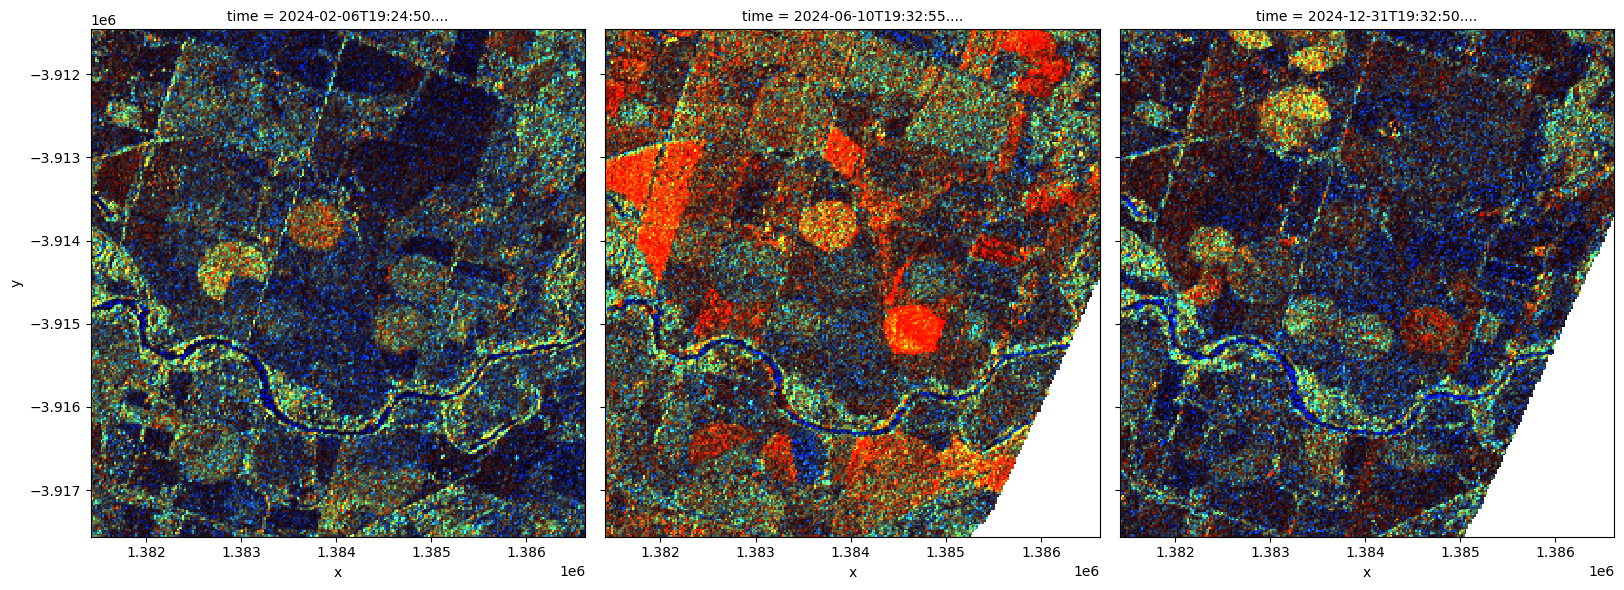

In [12]:
# plotting an RGB image for selected timesteps
time_steps = [0, 16, -1]

rgb(
    ds_s1[["VV", "VH", "vh/vv"]] / med_s1,  # normalize image ranges
    bands=["VV", "VH", "vh/vv"],
    index=time_steps,
    col_wrap=3
);

## Compute the radar vegetation index

This study measures the presence of vegetation through either the `Radar vegetation index (RVI)`.
 
The formula is

        RVI = 4*VH/(VV+VH)

RVI is available through the `dualpol_indices` function, imported from [deatools.bandindices](../Tools/deafrica_tools/bandindices.py).

In [13]:
# Calculate the chosen vegetation proxy index and add it to the loaded data set
ds_s1 = dualpol_indices(ds_s1, index="RVI")

## Plot the vegetation index over time

To get an idea of how the vegetation health changes throughout the year(s), we can plot a zonal time series over the region of interest. First we will do a simple plot of the zonal mean of the data.  


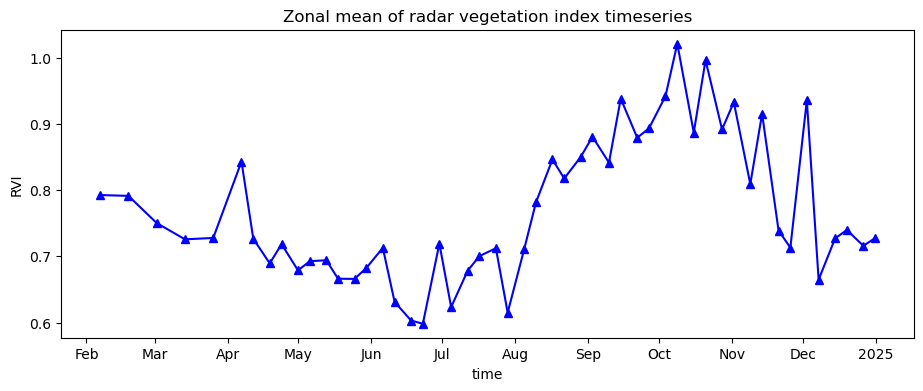

In [14]:
ds_s1.RVI.mean(["x", "y"]).plot.line("b-^", figsize=(11, 4))
plt.title("Zonal mean of radar vegetation index timeseries");

## Smoothing/Interpolating vegetation time-series

Here, we will smooth and interpolate the data to ensure we working with a consistent time-series. This is a very important step in the workflow and there are many ways to smooth, interpolate, gap-fill, remove outliers, or curve-fit the data to ensure a useable time-series. If not using the default example, you may have to define additional methods to those used here.

To do this we take two steps:

1. Resample the data to fortnightly time-steps using the fortnightly median
2. Calculate a rolling mean with a window of 4 steps


In [15]:
resample_period = "2W"
window = 4

rvi_smooth = (
    ds_s1.RVI.resample(time=resample_period)
    .mean()
    .rolling(time=window, min_periods=1)
    .mean()
)

Plot the smoothed and interpolated time-series

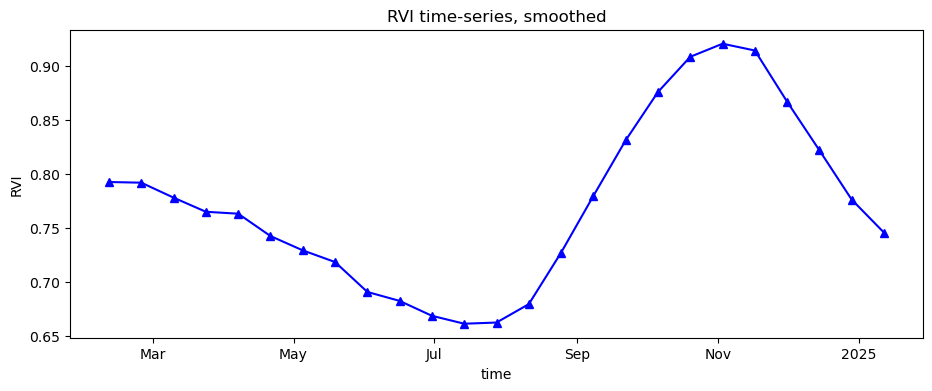

In [16]:
rvi_smooth_1D = rvi_smooth.mean(["x", "y"])
rvi_smooth_1D.plot.line("b-^", figsize=(11, 4))
_max = rvi_smooth_1D.max()
_min = rvi_smooth_1D.min()
plt.title("RVI time-series, smoothed")
plt.ylabel("RVI");

## Calculate phenology statistics using `xr_phenology`

The DEA function `xr_phenology` can calculate a number of land-surface phenology statistics that together describe the characteristics of a plant's lifecycle.  The function can calculate the following statistics on either a zonal timeseries (like the one above), or on a per-pixel basis:

        SOS = Date of start of season
        POS = Date of peak of season
        EOS = Date of end of season
        vSOS = Value at start of season
        vPOS = Value at peak of season
        vEOS = Value at end of season
        Trough = Minimum value of season
        LOS = Length of season (Days)
        AOS = Amplitude of season (in value units)
        ROG = Rate of greening
        ROS = Rate of senescence

By default the function will return all the statistics as an `xarray.Dataset`, to return only a subset of these statistics pass a list of the desired statistics to the function e.g. `stats=['SOS', 'EOS', 'ROG']`.

See the [dea_tools.temporal](../Tools/dea_tools/temporal.py) script for more information on each of the parameters in `xr_phenology`.


## Per-pixel phenology statistics

We can now calculate the statistics for every pixel in our time-series and plot the results.

In [17]:
phen = xr_phenology(
    rvi_smooth.sel(time='2024'),
    method_sos='median',
    method_eos='median',
    verbose=False,
)

At the top if the plotting code we re-mask the phenology results with the crop-mask. This is because `xr_phenology`has methods for handling pixels with only NaNs (such as those regions outside of the polygon mask), so the results can have phenology results for regions outside the mask. We will therefore have to mask the data again.


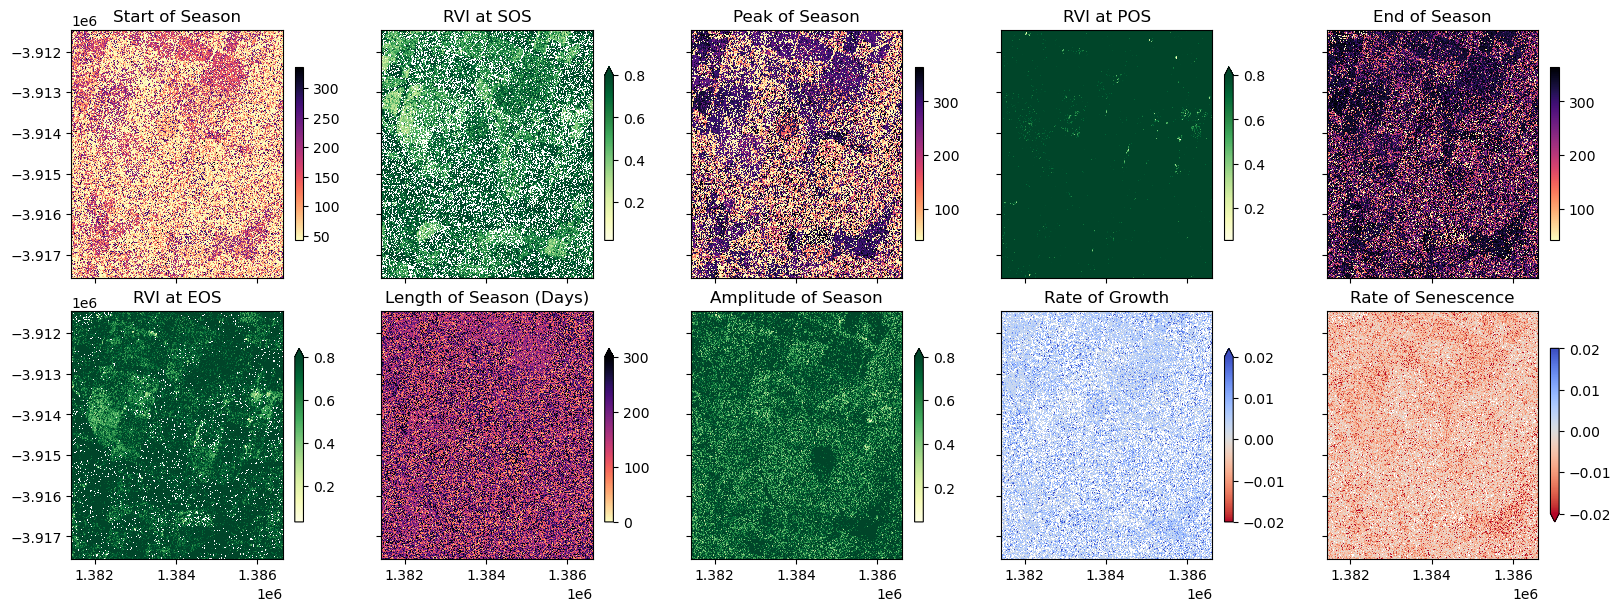

In [19]:
# set colorbar size
cbar_size = 0.7

# set up figure
fig, ax = plt.subplots(nrows=2,ncols=5,figsize=(16,6),sharex=True,sharey=True, layout='constrained')

# set aspect ratios
for a in fig.axes:
    a.set_aspect("equal")

# start of season
# Convert SOS values from np.date64 to float values for plotting
cax = phen.SOS.plot(ax=ax[0, 0],cmap="magma_r", add_colorbar=True, add_labels=False,
    cbar_kwargs=dict(shrink=cbar_size, label=None),
)
ax[0, 0].set_title("Start of Season")

phen.vSOS.plot(ax=ax[0, 1],cmap="YlGn",vmax=0.8,add_labels=False,
               cbar_kwargs=dict(shrink=cbar_size, label=None))
ax[0, 1].set_title("RVI at SOS")

# peak of season
cax = phen.POS.plot( ax=ax[0, 2],
    cmap="magma_r",
    add_colorbar=True,add_labels=False,
    cbar_kwargs=dict(shrink=cbar_size, label=None),
)
ax[0, 2].set_title("Peak of Season")

phen.vPOS.plot(ax=ax[0, 3],cmap="YlGn",vmax=0.8,add_labels=False,
            cbar_kwargs=dict(shrink=cbar_size, label=None))
ax[0, 3].set_title("RVI at POS")

# end of season
cax = phen.EOS.plot(ax=ax[0, 4],cmap="magma_r",add_colorbar=True,add_labels=False,
    cbar_kwargs=dict(shrink=cbar_size, label=None),
)
ax[0, 4].set_title("End of Season")

phen.vEOS.plot(ax=ax[1, 0],cmap="YlGn",vmax=0.8,add_labels=False,
               cbar_kwargs=dict(shrink=cbar_size, label=None))
ax[1, 0].set_title("RVI at EOS")

# Length of Season
phen.LOS.plot( ax=ax[1, 1],cmap="magma_r",vmax=300,vmin=0,add_labels=False,
    cbar_kwargs=dict(shrink=cbar_size, label=None),
)
ax[1, 1].set_title("Length of Season (Days)")

# Amplitude
phen.AOS.plot(ax=ax[1, 2],cmap="YlGn",vmax=0.8,add_labels=False,
              cbar_kwargs=dict(shrink=cbar_size, label=None))
ax[1, 2].set_title("Amplitude of Season")

# rate of growth
phen.ROG.plot(ax=ax[1, 3], cmap="coolwarm_r",vmin=-0.02,vmax=0.02,add_labels=False,
    cbar_kwargs=dict(shrink=cbar_size, label=None),
)
ax[1, 3].set_title("Rate of Growth")

# rate of Sensescence
phen.ROS.plot(ax=ax[1, 4],cmap="coolwarm_r",vmin=-0.02,vmax=0.02,add_labels=False,
    cbar_kwargs=dict(shrink=cbar_size, label=None),
)
ax[1, 4].set_title("Rate of Senescence");

## Conclusions

In the example above, we can see most of the fields are following a similar cropping schedule and are therefore likely the same species of crop. We can also observe that some fields have not followed this schedule (e.g. the EOY plot shows some fields didn't follow this schedule, probably because they either remained fallow during the year, or because there were two peaks during the year which may have confused the phenology stats).  Differences in the rates of growth, and in the RVI values at different times of the season, may be attributable to differences in soil quality, watering intensity, or other farming practices. 

Phenology statistics are a powerful way to summarise the seasonal cycle of a plant's life.  Per-pixel plots of phenology can help us understand the timing of vegetation growth and sensecence across large areas and across diverse plant species as every pixel is treated as an independent series of observations. This could be important, for example, if we wanted to assess how the growing seasons are shifting as the climate warms.  


***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** July 2025

**Compatible datacube version:** |

In [ ]:
print(datacube.__version__)